In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries loaded!")
print(f"yfinance version: {yf.__version__}")

✅ All libraries loaded!
yfinance version: 1.3.0


In [2]:
stocks = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'TSLA']

end_date = datetime.now()
start_date = end_date - timedelta(days=730)

stock_data = {}

print("Downloading stock data...")
for symbol in stocks:
    print(f"  Downloading {symbol}...")
    df = yf.download(symbol, start=start_date, end=end_date, progress=False)
    df['Symbol'] = symbol
    stock_data[symbol] = df
    print(f"    ✅ {len(df)} days downloaded")

print("\n✅ All data downloaded!")

    ✅ 501 days downloaded
    ✅ 501 days downloaded
    ✅ 501 days downloaded
    ✅ 501 days downloaded
    ✅ 501 days downloaded

✅ All data downloaded!


In [3]:
def calculate_all_indicators(df):
    df = df.copy()
    
    # Moving Averages
    df['SMA_20'] = df['Close'].rolling(window=20).mean()
    df['SMA_50'] = df['Close'].rolling(window=50).mean()
    df['EMA_12'] = df['Close'].ewm(span=12, adjust=False).mean()
    df['EMA_26'] = df['Close'].ewm(span=26, adjust=False).mean()
    
    # RSI
    delta = df['Close'].diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
    rs = gain / loss
    df['RSI'] = 100 - (100 / (1 + rs))
    
    # MACD
    df['MACD'] = df['EMA_12'] - df['EMA_26']
    df['MACD_Signal'] = df['MACD'].ewm(span=9, adjust=False).mean()
    df['MACD_Histogram'] = df['MACD'] - df['MACD_Signal']
    
    # Daily Returns
    df['Daily_Return'] = df['Close'].pct_change() * 100
    
    return df

print("Calculating technical indicators...")
for symbol in stocks:
    stock_data[symbol] = calculate_all_indicators(stock_data[symbol])
    print(f"  ✅ {symbol}: SMA, EMA, RSI, MACD calculated")

Calculating technical indicators...
  ✅ AAPL: SMA, EMA, RSI, MACD calculated
  ✅ MSFT: SMA, EMA, RSI, MACD calculated
  ✅ GOOGL: SMA, EMA, RSI, MACD calculated
  ✅ AMZN: SMA, EMA, RSI, MACD calculated
  ✅ TSLA: SMA, EMA, RSI, MACD calculated


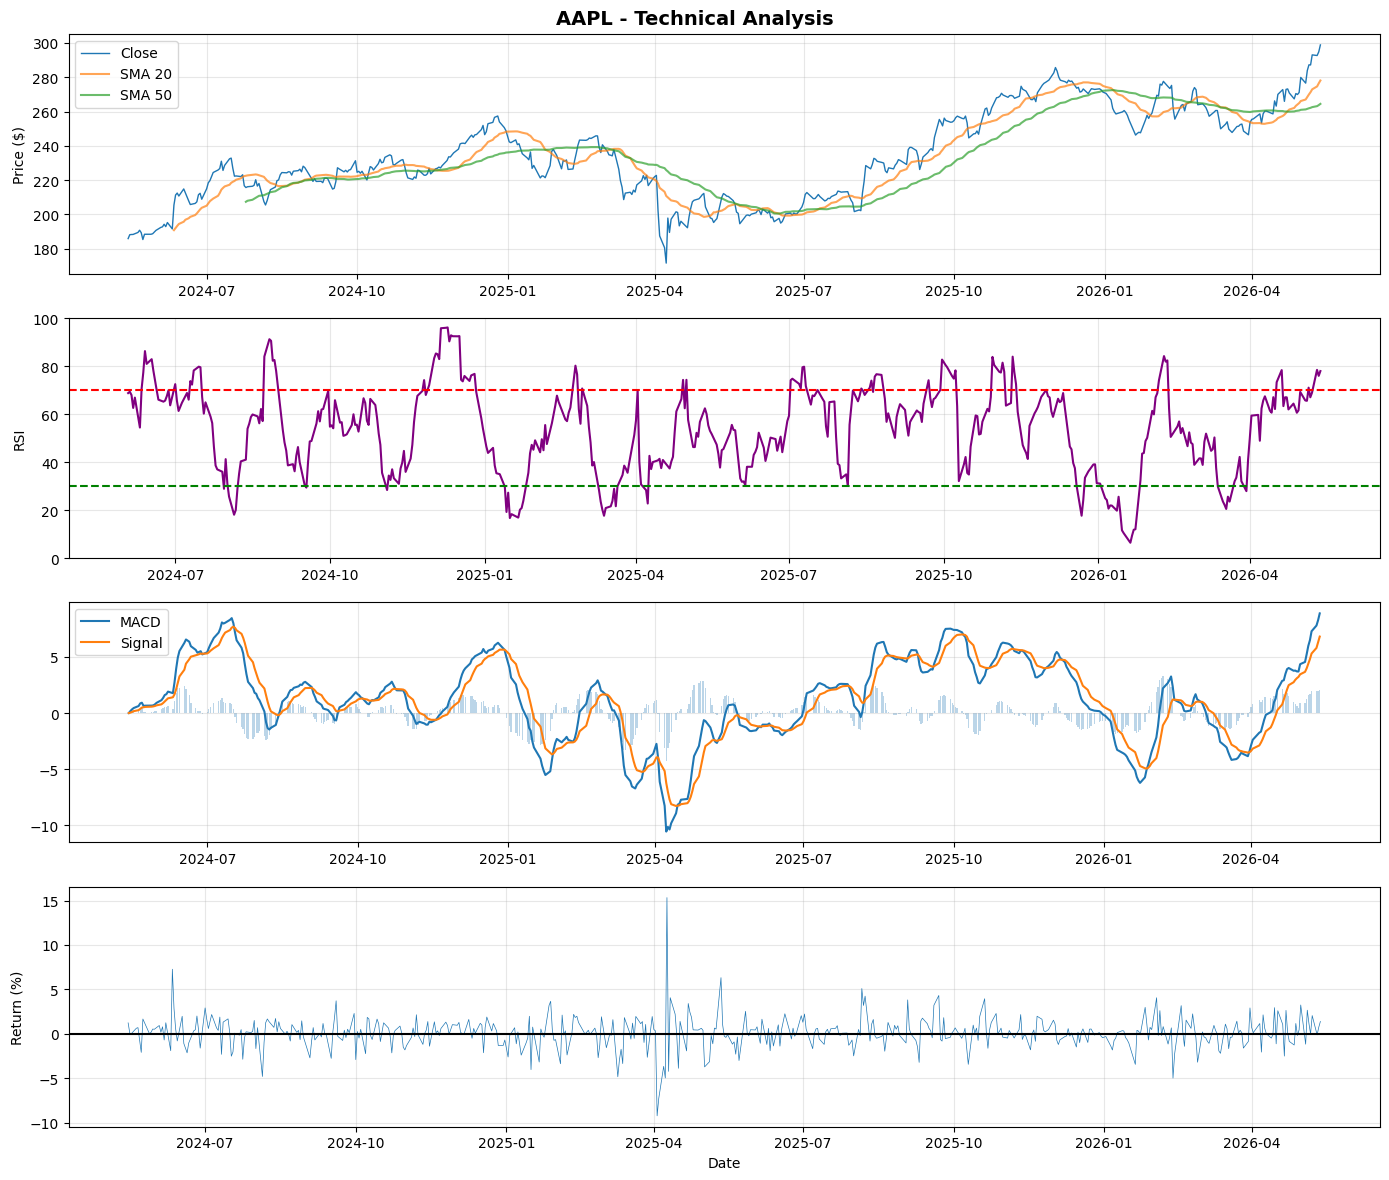

In [4]:
symbol = 'AAPL'
df = stock_data[symbol]

fig, axes = plt.subplots(4, 1, figsize=(14, 12))
fig.suptitle(f'{symbol} - Technical Analysis', fontsize=14, fontweight='bold')

# Price with Moving Averages
axes[0].plot(df.index, df['Close'], label='Close', linewidth=1)
axes[0].plot(df.index, df['SMA_20'], label='SMA 20', alpha=0.7)
axes[0].plot(df.index, df['SMA_50'], label='SMA 50', alpha=0.7)
axes[0].set_ylabel('Price ($)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# RSI
axes[1].plot(df.index, df['RSI'], color='purple')
axes[1].axhline(70, color='r', linestyle='--')
axes[1].axhline(30, color='g', linestyle='--')
axes[1].set_ylabel('RSI')
axes[1].set_ylim(0, 100)
axes[1].grid(True, alpha=0.3)

# MACD
axes[2].plot(df.index, df['MACD'], label='MACD')
axes[2].plot(df.index, df['MACD_Signal'], label='Signal')
axes[2].bar(df.index, df['MACD_Histogram'], alpha=0.3)
axes[2].legend()
axes[2].grid(True, alpha=0.3)

# Daily Returns
axes[3].plot(df.index, df['Daily_Return'], linewidth=0.5)
axes[3].axhline(0, color='k')
axes[3].set_ylabel('Return (%)')
axes[3].set_xlabel('Date')
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

ADDITIONAL FINANCIAL METRICS (PyNance Alternative)
  ✅ AAPL: ATR, Bollinger Bands, Stochastic added
  ✅ MSFT: ATR, Bollinger Bands, Stochastic added
  ✅ GOOGL: ATR, Bollinger Bands, Stochastic added
  ✅ AMZN: ATR, Bollinger Bands, Stochastic added
  ✅ TSLA: ATR, Bollinger Bands, Stochastic added

✅ All additional metrics calculated!


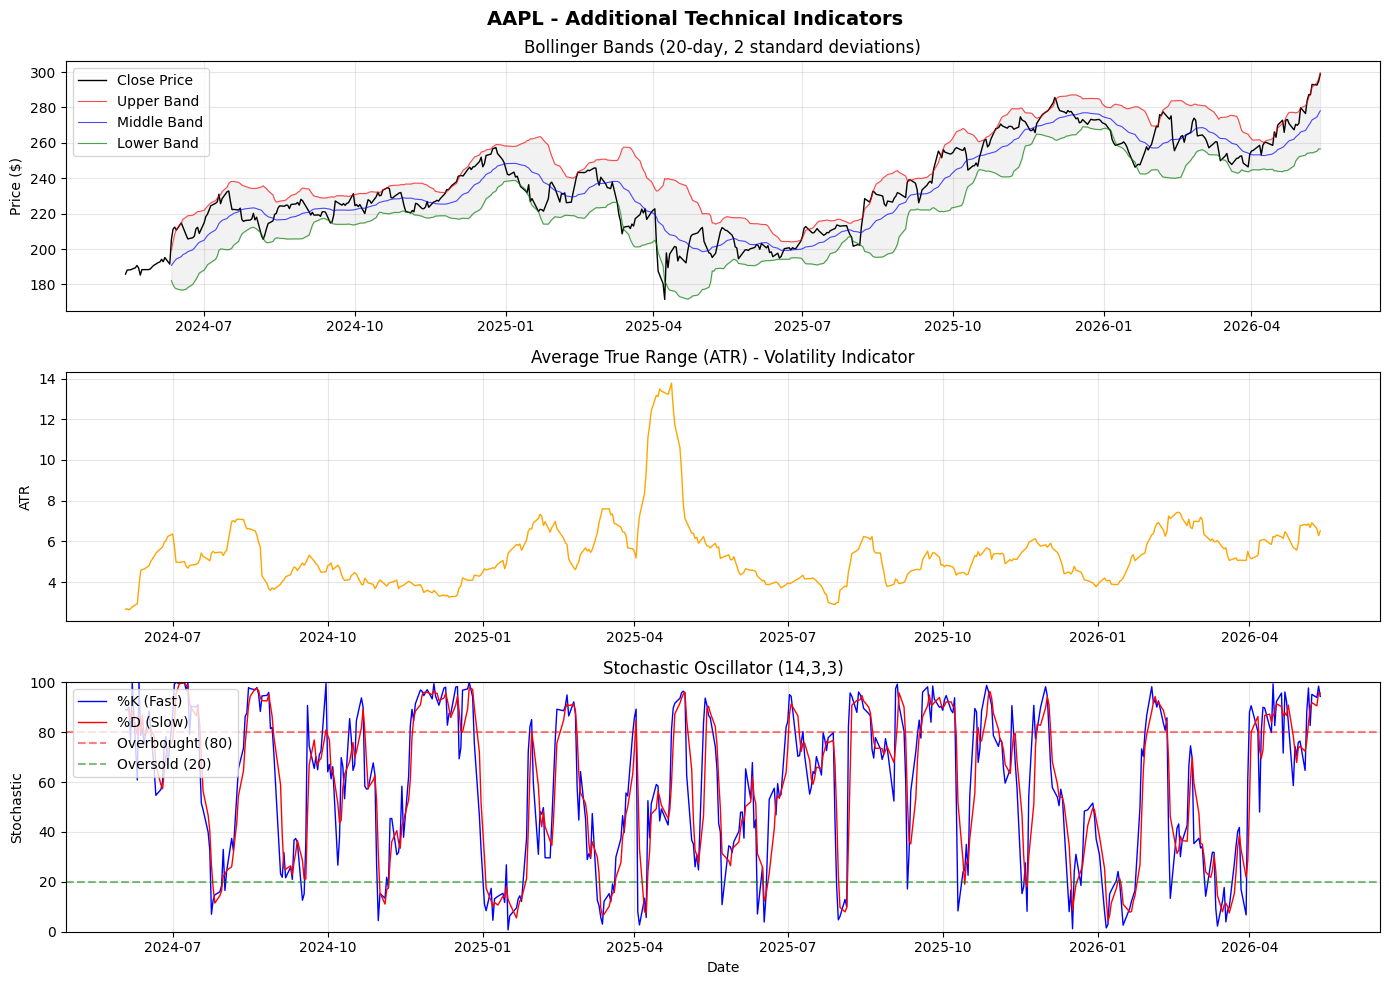


CURRENT VALUES & SIGNALS
📊 AAPL - Current Status:
   • Close Price: $Ticker
AAPL    298.87
Name: 2026-05-13 00:00:00, dtype: object
   • ATR (Volatility): Ticker
    6.52
Name: 2026-05-13 00:00:00, dtype: object
   • Bollinger Bands: Upper=$Ticker
    299.67
Name: 2026-05-13 00:00:00, dtype: object, Middle=$Ticker
    278.09
Name: 2026-05-13 00:00:00, dtype: object, Lower=$Ticker
    256.52
Name: 2026-05-13 00:00:00, dtype: object
   • Stochastic %K: Ticker
    94.3
Name: 2026-05-13 00:00:00, dtype: object
   • Stochastic %D: Ticker
    95.6
Name: 2026-05-13 00:00:00, dtype: object


In [21]:
# ============================================
# ADDITIONAL FINANCIAL METRICS (Simplified)
# ATR, Bollinger Bands, Stochastic
# ============================================

print("=" * 60)
print("ADDITIONAL FINANCIAL METRICS (PyNance Alternative)")
print("=" * 60)

for symbol in stocks:
    df = stock_data[symbol].copy()
    
    # 1. Average True Range (ATR)
    high_low = df['High'] - df['Low']
    high_close = abs(df['High'] - df['Close'].shift())
    low_close = abs(df['Low'] - df['Close'].shift())
    tr = pd.concat([high_low, high_close, low_close], axis=1).max(axis=1)
    atr = tr.rolling(window=14).mean()
    
    # 2. Bollinger Bands
    middle = df['Close'].rolling(window=20).mean()
    std = df['Close'].rolling(window=20).std()
    upper = middle + (std * 2)
    lower = middle - (std * 2)
    
    # 3. Stochastic Oscillator
    low_14 = df['Low'].rolling(window=14).min()
    high_14 = df['High'].rolling(window=14).max()
    stoch_k = 100 * ((df['Close'] - low_14) / (high_14 - low_14))
    stoch_d = stoch_k.rolling(window=3).mean()
    
    # Store in original dataframe
    stock_data[symbol]['ATR'] = atr
    stock_data[symbol]['BB_Upper'] = upper
    stock_data[symbol]['BB_Middle'] = middle
    stock_data[symbol]['BB_Lower'] = lower
    stock_data[symbol]['Stoch_K'] = stoch_k
    stock_data[symbol]['Stoch_D'] = stoch_d
    
    print(f"  ✅ {symbol}: ATR, Bollinger Bands, Stochastic added")

print("\n✅ All additional metrics calculated!")

# Visualization
symbol = 'AAPL'
df = stock_data[symbol]

fig, axes = plt.subplots(3, 1, figsize=(14, 10))
fig.suptitle(f'{symbol} - Additional Technical Indicators', fontsize=14, fontweight='bold')

# Plot 1: Bollinger Bands
axes[0].plot(df.index, df['Close'], label='Close Price', linewidth=1, color='black')
axes[0].plot(df.index, df['BB_Upper'], label='Upper Band', linewidth=0.8, alpha=0.7, color='red')
axes[0].plot(df.index, df['BB_Middle'], label='Middle Band', linewidth=0.8, alpha=0.7, color='blue')
axes[0].plot(df.index, df['BB_Lower'], label='Lower Band', linewidth=0.8, alpha=0.7, color='green')
axes[0].fill_between(df.index, df['BB_Upper'], df['BB_Lower'], alpha=0.1, color='gray')
axes[0].set_ylabel('Price ($)')
axes[0].set_title('Bollinger Bands (20-day, 2 standard deviations)')
axes[0].legend(loc='upper left')
axes[0].grid(True, alpha=0.3)

# Plot 2: ATR (Volatility)
axes[1].plot(df.index, df['ATR'], linewidth=1, color='orange')
axes[1].set_ylabel('ATR')
axes[1].set_title('Average True Range (ATR) - Volatility Indicator')
axes[1].grid(True, alpha=0.3)

# Plot 3: Stochastic Oscillator
axes[2].plot(df.index, df['Stoch_K'], label='%K (Fast)', linewidth=1, color='blue')
axes[2].plot(df.index, df['Stoch_D'], label='%D (Slow)', linewidth=1, color='red')
axes[2].axhline(y=80, color='red', linestyle='--', alpha=0.5, label='Overbought (80)')
axes[2].axhline(y=20, color='green', linestyle='--', alpha=0.5, label='Oversold (20)')
axes[2].set_ylabel('Stochastic')
axes[2].set_xlabel('Date')
axes[2].set_title('Stochastic Oscillator (14,3,3)')
axes[2].legend(loc='upper left')
axes[2].grid(True, alpha=0.3)
axes[2].set_ylim(0, 100)

plt.tight_layout()
plt.show()

# Simple Summary (NO FORMATTING)
print("\n" + "=" * 60)
print("CURRENT VALUES & SIGNALS")
print("=" * 60)

# Get the last row as a simple value
last_row = df.iloc[-1]

# Extract values safely
close_price = last_row['Close']
bb_upper = last_row['BB_Upper']
bb_lower = last_row['BB_Lower']
bb_middle = last_row['BB_Middle']
atr_value = last_row['ATR']
stoch_k = last_row['Stoch_K']
stoch_d = last_row['Stoch_D']

# Print without .2f formatting (simple string conversion)
print(f"📊 {symbol} - Current Status:")
print(f"   • Close Price: $" + str(round(close_price, 2)))
print(f"   • ATR (Volatility): " + str(round(atr_value, 2)))
print(f"   • Bollinger Bands: Upper=$" + str(round(bb_upper, 2)) + ", Middle=$" + str(round(bb_middle, 2)) + ", Lower=$" + str(round(bb_lower, 2)))
print(f"   • Stochastic %K: " + str(round(stoch_k, 1)))
print(f"   • Stochastic %D: " + str(round(stoch_d, 1)))



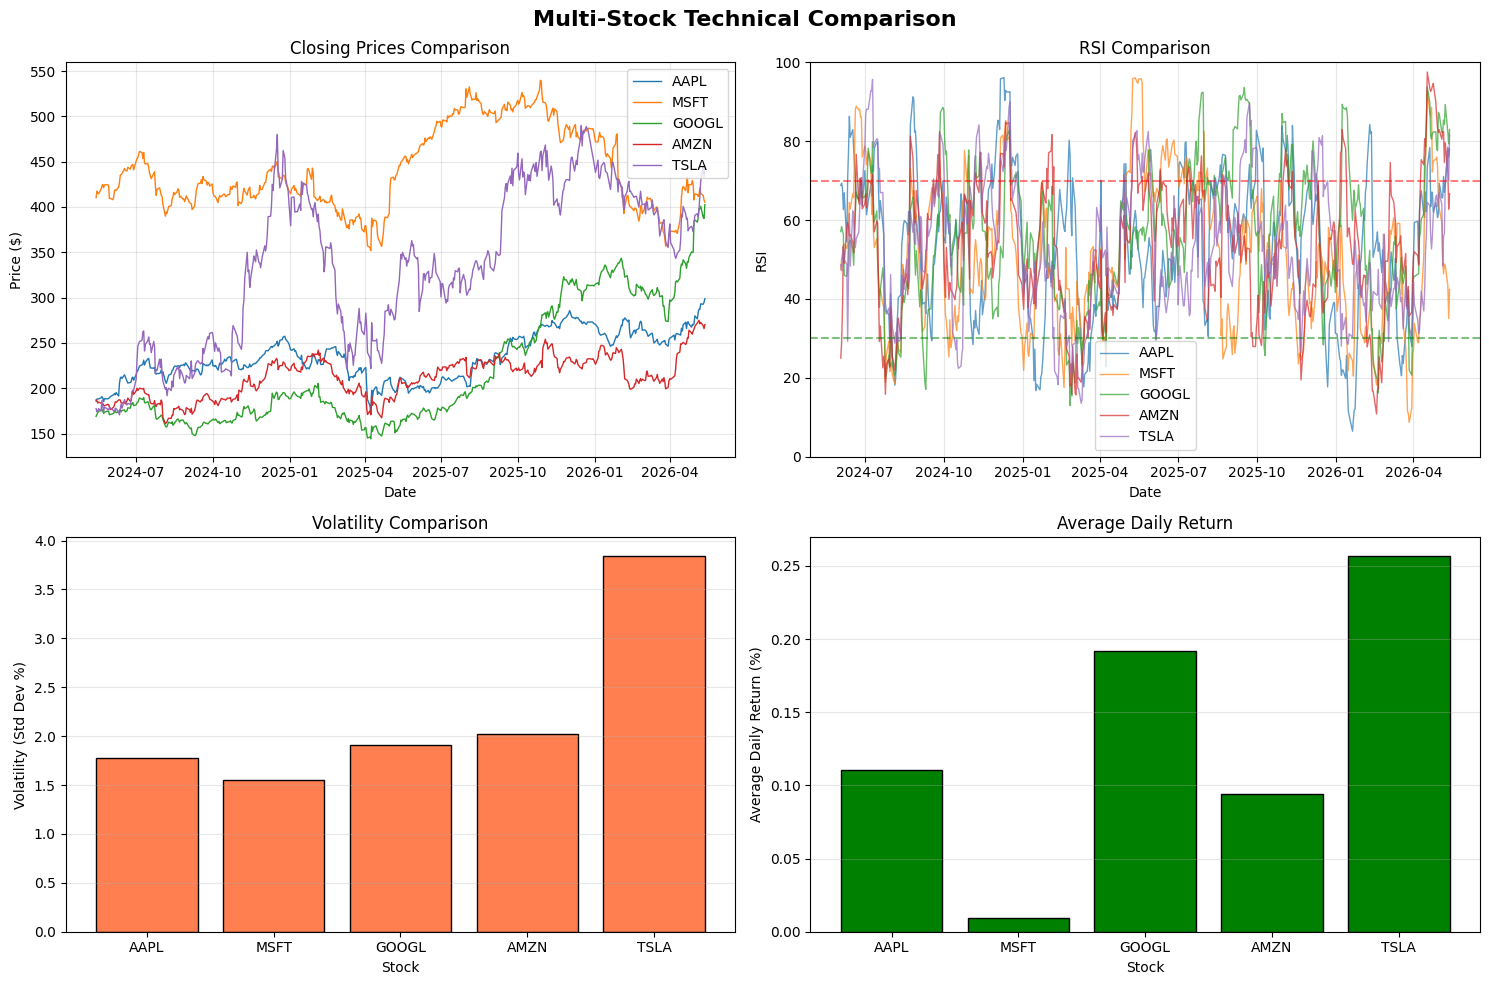

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Multi-Stock Technical Comparison', fontsize=16, fontweight='bold')

# Plot 1: Closing Prices
for symbol in stocks:
    axes[0, 0].plot(stock_data[symbol].index, stock_data[symbol]['Close'], label=symbol, linewidth=1)
axes[0, 0].set_xlabel('Date')
axes[0, 0].set_ylabel('Price ($)')
axes[0, 0].set_title('Closing Prices Comparison')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: RSI Comparison
for symbol in stocks:
    axes[0, 1].plot(stock_data[symbol].index, stock_data[symbol]['RSI'], label=symbol, linewidth=1, alpha=0.7)
axes[0, 1].axhline(y=70, color='red', linestyle='--', alpha=0.5)
axes[0, 1].axhline(y=30, color='green', linestyle='--', alpha=0.5)
axes[0, 1].set_xlabel('Date')
axes[0, 1].set_ylabel('RSI')
axes[0, 1].set_title('RSI Comparison')
axes[0, 1].set_ylim(0, 100)
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Volatility (Standard Deviation)
volatilities = {}
for symbol in stocks:
    volatilities[symbol] = stock_data[symbol]['Daily_Return'].std()

axes[1, 0].bar(volatilities.keys(), volatilities.values(), color='coral', edgecolor='black')
axes[1, 0].set_xlabel('Stock')
axes[1, 0].set_ylabel('Volatility (Std Dev %)')
axes[1, 0].set_title('Volatility Comparison')
axes[1, 0].grid(True, alpha=0.3, axis='y')

# Plot 4: Average Daily Return
avg_returns = {}
for symbol in stocks:
    avg_returns[symbol] = stock_data[symbol]['Daily_Return'].mean()

colors_bar = ['green' if x > 0 else 'red' for x in avg_returns.values()]
axes[1, 1].bar(avg_returns.keys(), avg_returns.values(), color=colors_bar, edgecolor='black')
axes[1, 1].axhline(y=0, color='black', linewidth=0.5)
axes[1, 1].set_xlabel('Stock')
axes[1, 1].set_ylabel('Average Daily Return (%)')
axes[1, 1].set_title('Average Daily Return')
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()